# Podstawowe instrukcje i metody biblioteki Pandas

### 1. Tworzenie i eksploracja struktur danych
* **`import pandas as pd`** - Importuje bibliotekę Pandas do skryptu [1].
* **`pd.Series(data, index)`** - Tworzy jednowymiarową strukturę danych z indeksami, funkcjonującą jako pojedyncza kolumna [1, 2].
* **`pd.DataFrame(data, columns)`** - Tworzy dwuwymiarową strukturę tabelaryczną (składającą się z wierszy i kolumn) z danymi wejściowymi, takimi jak słowniki lub tablice NumPy [1-3].
* **`df.head(n)`** - Wyświetla pierwsze `n` wierszy z DataFrame, domyślnie jest to 5 wierszy [4, 5].
* **`df.shape`** - Zwraca krotkę z dokładnymi wymiarami tabeli, ułożoną w formacie `(liczba_wierszy, liczba_kolumn)` [3].
* **`df.columns.tolist()`** - Zwraca standardową listę zawierającą nazwy wszystkich kolumn [3].
* **`df.dtypes`** - Wyświetla typy danych zastosowane w każdej z poszczególnych kolumn [3].
* **`df.info()`** - Podaje bardzo szczegółowe informacje ogólne na temat struktury, w tym wykorzystane typy danych, liczbę komórek non-null oraz finalne zużycie pamięci [6, 7].
* **`df.describe()`** - Oblicza kluczowe statystyki opisowe dla danych numerycznych (m.in. count, mean, std, min, max, medianę) [4, 5].

### 2. Importowanie i zapisywanie danych (Opcje Green IT)
* **`pd.read_csv(...)`** - Służy do odczytywania danych z klasycznych plików CSV oraz bezpośrednio z adresów internetowych URL [8, 9]. Akceptuje wiele optymalizujących parametrów:
  * `sep=';'` - Ustawia własny znak pełniący rolę separatora danych [10, 11].
  * `encoding='utf-8'` - Deklaruje rodzaj kodowania tekstu w pliku [10, 11].
  * `index_col='kolumna'` - Wskazuje konkretną kolumnę, która posłuży jako docelowy indeks [10, 11].
  * `usecols=['kol1', 'kol2']` - Zawęża proces wczytywania wyłącznie do wskazanych kolumn, znacząco oszczędzając tym samym cenną pamięć RAM [10, 11].
  * `skiprows=` - Omija wskazane wiersze, na przykład początkowe nagłówki [11].
  * `nrows=n` - Limituje ładowanie pliku tylko do określonej liczby `n` wierszy, bardzo przydatne przy wstępnych testach [11, 12].
  * `chunksize=n` - Dzieli bardzo duże pliki na batche (kawałki). Chroni przed przeciążeniem RAM-u nie wczytując całego wielkiego pliku na raz, w zamian zwracając dedykowany iterator [12, 13].
* **`pd.read_excel()`**, **`pd.read_sql()`**, **`pd.read_json()`** - Służą do wczytywania danych odpowiednio ze standardowych arkuszy kalkulacyjnych Excela, obsługiwanych baz SQL oraz ustrukturyzowanych plików w standardzie JSON [7, 14].
* **`pd.concat()`** - Odpowiada za łączenie wielu drobnych struktur DataFrame (np. zebranych z działania batch processingu) w jednolitą i zbiorczą tabelę [13, 15].

### 3. Filtrowanie i selekcja zawartości
* **`df['nazwa_kolumny']`** lub **`df.nazwa_kolumny`** - Wybiera wskazaną pojedynczą kolumnę (rezultatem jest mniejszy obiekt typu Series) [5, 16, 17].
* **`df[['kol1', 'kol2']]`** - Służy do jednoczesnego wyboru wielu kolumn [16, 17].
* **`df.iloc[wiersze, kolumny]`** - Służy do ścisłej selekcji wykorzystującej fizyczne numery pozycji, bazujące na matematycznych liczbach całkowitych. Przy wycinaniu zakresów tzw. wartość `stop` jest wykluczona (nie wlicza się do podsumowania) [17, 18].
* **`df.loc[wiersze, kolumny]`** - Służy do precyzyjnej selekcji wykorzystującej znane nazwy, czyli etykiety kolumn/wierszy. Tutaj punkt graniczny (`stop`) znajduje się całkowicie w zakresie wycinka [17, 18].
* **Filtrowanie (Boolean indexing)** np. `df[df['Wiek'] > 18]` - Wyodrębnia te wiersze z całej zbiorowości, które zwracają odpowiedź logiczną "Prawda" dla danego warunku [16, 19]. Bardziej złożone warunki trzeba koniecznie zawrzeć w osobnych nawiasach i spinać znakami logicznymi `&` (AND), `|` (OR), lub odwracać przez `~` (negacja NOT) [19].
* **`df['kolumna'].isin(lista)`** - Przeszukuje kolumnę i potwierdza, czy występujące tam dane pokrywają się z wartościami wymienionymi na podręcznej liście kontrolnej [19, 20].
* **`df.query("warunki")`** - Oferuje zoptymalizowaną, wysoce czytelną tekstowo składnię pozwalającą filtrować bez mnożenia ciągłego wywoływania nawiasów; pozwala posługiwać się znakiem `@` aby skutecznie mapować zmienne spoza DataFrame [21, 22].
* **`df.filter()`** - Przeczesuje cały zbiór, odfiltrowując i w efekcie zwracając wyłącznie KOLUMNY na bazie ich nazw - w tym celu korzysta z podciągów znaków (argument `like`) lub potężnych wyrażeń regularnych (argument `regex`) [22, 23].

### 4. Transformacje oraz operacje na danych
* **`df.copy()`** - Definiuje w kodzie w pełni głęboką kopię zapasową DataFrame ułatwiającą bezpieczne testowanie czyszczenia danych [24].
* **`df.sort_values(kolumna, ascending=False)`** - Bierze całą tabelę i dokonuje kompleksowego sortowania zawartości według konkretnie podanej kolumny [6, 7].
* **`df.mean()`, `df.max()`, `df.min()`, `df.median()`, `df.mode()`** - Obliczają główne wskaźniki używane w statystyce takie jak średnia, najwyższa zanotowana wartość, minimalny dołek, wartość środkowa rzędu, a także najpopularniejszy wynik (dominanta). Argumentowanie ich za pomocą `axis=1` przerzuca domyślne przeliczenia dokonywane wzdłuż kolumn na płaszczyznę poszczególnych wierszy horyzontalnych [1, 6, 24, 25].
* **`df['kolumna'].value_counts()`** - Maszynowo liczy i sumuje częstość występowania danej wartości kategorycznej w konkretnej kolumnie [25, 26].
* **`df.groupby(...)`** - Służy do ścisłego grupowania zestawu bazując na jakiejś powtarzalnej i docelowej grupie (np. klasie pasażera) [23].
* **`df.groupby(...).agg(['sum', 'count'])`** - Służy do nakładania i przeprowadzania operacji agregujących (takich jak dodawanie i całkowite liczenie obecnych komórek) na rozłożone do grup obszary informacyjne [23].
* **`df.pivot_table(...)`** - Dokonuje transformacji zgromadzonych wyników i formatuje z nich niezwykle sprawną dwuwymiarową tabelę przestawną [23].
* **`pd.date_range(...)`** - Buduje systematyczny i powtarzalny zakres składający się z kolejnych interwałów w zadanym zakresie czasowym/datach [27].
* **`df.set_index('kolumna', inplace=True)`** - Promuje narzuconą wybraną kolumnę z powszechnego rekordu na rolę ostatecznego klucza kategoryzującego (wzorcowego indeksu całego układu zbioru) [28].
* **`df.drop('kolumna', axis=1, inplace=True)`** - Metoda trwale degradująca, wykluczająca i usuwająca kolumnę ze standardowych rezerw posiadanego układu analizy [29].
* **`pd.cut(df['kolumna'], bins, labels)`** - Technika szufladkowania numerycznego służąca przydzielaniu danych obracających się wokół surowych ułamków/liczb w odpowiednie etykiety - np. przedziały podatkowe, kategorie wiekowe [30].

### 5. Strategie pracy z wybrakowanymi wpisami (Oznaczonymi jako NaN)
* **`df.isnull()`** lub **`df.isna()`** - W miejsce każdej poszczególnej komórki wypluwa zwrotną logiczną flagę: słowo `True` (oznaczające potężny brak danych, lukę typu NaN) lub zaprzeczenie `False` (dane zachowane) [31, 32].
* **`df.isnull().sum()`** - Sprawdza dla wszystkich kolumn z absolutną dokładnością ile posiadają pustych komórek zakwalifikowanych formalnie jako ubytki (NaN) [31, 32].
* **`df.isnull().any(axis=1)`** - Funkcja weryfikująca wiersze badająca, czy gdzieś na długości pojedynczej lini prostej umiejscowiła się chociaż jedna pusta przestrzeń traktowana jako komórka NaN [32, 33].
* **`df.dropna(...)`** - Wybitnie destrukcyjna metoda pozbywania się błędnych wierszy posiadających luki. Opcjonalne modyfikatory działania:
  * `how='all'` - Rozkazuje programowi zabić linię wyłącznie kiedy wszystkie przypisane komórki informacyjne są puste, absolutnie zniszczone [34, 35].
  * `subset=['kolumna']` - Skupia algorytm poszukiwań braków i kasowania pustych wpisów koncentrując moc wyłącznie do zdeklarowanej w parametrach kolumnie analizowanej [34, 35].
  * `thresh=n` - Utrzymuje w puli jedynie wiersze, którym udało się przejść próg akceptowalności posiadające co najmniej absolutne i surowe minimum równe do `n` pełnoprawnych wartości numerycznych/poprawnych danych [34, 35].
  * `axis=1` - Totalnie modyfikuje trajektorię, powodując wykasowywanie absolutnie caluteńkich pustych kolumn zamiast wycinania tylko nieznacznie podziurawionych wierszy [34, 35].
* **`df.fillna(wartość, inplace=True)`** - Odpowiada za sprytne "zalepianie" przerw wprowadzając w pola o charakterze luki `NaN` stałe liczby/wytyczne tekstowe, często z automatu dopisując wyniki używając opcji modyfikacji lokalnej `inplace=True` bez przypisywania do innej zmiennej [24, 27].
  * `method='ffill'` - Wariant służący zaciągnięciu wartości do pustego pola NaN wprost z wiersza leżącego wyżej i jej sztucznemu wydłużeniu na braki idąc ku dołowi [27, 36].
  * `method='bfill'` - Robi dokładnie na odwrót, szuka zapisu nadającego się u samego dołu wolnej przestrzeni by z powrotem odkręcić lukę propagując wartość kierującą się pędem na wolne rubryczki [27, 36].
* **`df.interpolate(method='...')`** - Wykonuje estymację nieciągłości; metoda liniowa tworzy płynną wirtualną prostą wyliczoną w poprzek wyrwy, po czym maskuje punkt używając `method='linear'`, natomiast precyzyjna kategoryzacja czasu dopasuje w miarę bliskie wartości pod znacznik w kalendarzu korzystając z dyspozycji `method='time'` [28, 37].

### 6. Pamięć, Optymalizacja oraz Ekologia Informatyczna
* **`df.memory_usage(deep=True)`** - System weryfikacyjny, dokonujący precyzyjnego odczytu gigabajtów zużywanych w trzewiach operacyjnej kości RAM na obróbkę badanej struktury w rozłożeniu mikrometrycznym z dogłębnym badaniem alokacji [38, 39].
* **`df['kolumna'].astype('typ_danych')`** - Rewolucyjna instrukcja wymuszająca radykalną transformację formatu danych pozwalająca dokonywać skrupulatnego oszczędzania megabajtów. Powszechne zabiegi dążą do przesunięcia szerokiego rozmiaru `int64` na maksymalnie zminiaturyzowany gabaryt domniemanych wartości typując na `int8`, analogicznie do typowych ułamków uciekając przykładowo na ciut rzadszą klasę alokacji `float32`, natomiast pola oparte na słowach lub statusach i napisane w powolnym systemie odczytu formy tekstowej zwanej powszechnie `object` błyskawicznie przepisuje do skondensowanego typu systemowego `category` [39, 40].

Przykład 1: Tworzenie Series i DataFrame - Podstawy

In [6]:
import pandas as pd
import numpy as np
#kolumna jednowymiarowa
temperatures = pd.Series([22.5, 23.1, 21.8, 24.2, 22.9],index = ["Poniedziałek", "Wtorek", "Środa" ,"Czwartek", "Piątek"])
print("Series - temeratury")
print(temperatures)

#Dataframe - dwuwymiarowa struktura tabela
data = {
    "Produkt": ["Laptop", "Mysz", "Klawiatura", "Monitor", "Słuchawki"],
    "Cena": [3500, 80, 250, 1200, 350],
    "Sprzedane:": [45,320,150,78,210],
    "Ocena" : [4.5, 4.2, 4.7, 4.4, 4.3]

}

df = pd.DataFrame(data)
print("Data Frame:")
print(df)


#podstawowe informacje:

print(f"\nKształt:{df.shape}") #wiersze,, kolumny
print(f"Kolumny: {df.columns.tolist()}")
print(f"Typy danych: {df.dtypes}")

Series - temeratury
Poniedziałek    22.5
Wtorek          23.1
Środa           21.8
Czwartek        24.2
Piątek          22.9
dtype: float64
Data Frame:
      Produkt  Cena  Sprzedane:  Ocena
0      Laptop  3500          45    4.5
1        Mysz    80         320    4.2
2  Klawiatura   250         150    4.7
3     Monitor  1200          78    4.4
4   Słuchawki   350         210    4.3

Kształt:(5, 4)
Kolumny: ['Produkt', 'Cena', 'Sprzedane:', 'Ocena']
Typy danych: Produkt           str
Cena            int64
Sprzedane:      int64
Ocena         float64
dtype: object


In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

dane_numeryczne = np.random.randn(100,4)

df_numpy = pd.DataFrame(dane_numeryczne,
                        columns=["CechaA", "CechaB", "CechaC", "CechaD"])
print(f"Data Frame z NUmpy")
print(df_numpy.head())

#podstawowe statystyki
print(df_numpy.describe()) #count, mean, std, miin, 25%, 50%, 75%, max

#dostep do kolumn
print(df_numpy["CechaA"].head(10))

#dodanie nowej kolumny
df_numpy["Nazwa nowej kolumny"] = df_numpy["CechaA"] + df_numpy["CechaB"]
df_numpy.head()

Data Frame z NUmpy
     CechaA    CechaB    CechaC    CechaD
0  0.496714 -0.138264  0.647689  1.523030
1 -0.234153 -0.234137  1.579213  0.767435
2 -0.469474  0.542560 -0.463418 -0.465730
3  0.241962 -1.913280 -1.724918 -0.562288
4 -1.012831  0.314247 -0.908024 -1.412304
           CechaA      CechaB      CechaC      CechaD
count  100.000000  100.000000  100.000000  100.000000
mean    -0.009811    0.033746    0.022496    0.043764
std      0.868065    0.952234    1.044014    0.982240
min     -2.025143   -1.959670   -3.241267   -1.987569
25%     -0.716089   -0.564362   -0.616727   -0.727600
50%     -0.000248   -0.024646    0.068665    0.075219
75%      0.528231    0.547116    0.701519    0.778891
max      2.314659    3.852731    2.189803    2.720169
0    0.496714
1   -0.234153
2   -0.469474
3    0.241962
4   -1.012831
5    1.465649
6   -0.544383
7   -0.600639
8   -0.013497
9    0.208864
Name: CechaA, dtype: float64


,CechaA,CechaB,CechaC,CechaD,Nazwa nowej kolumny
0,0.496714,-0.138264,0.647689,1.523030,0.358450
1,-0.234153,-0.234137,1.579213,0.767435,-0.468290
2,-0.469474,0.542560,-0.463418,-0.465730,0.073086
3,0.241962,-1.913280,-1.724918,-0.562288,-1.671318
4,-1.012831,0.314247,-0.908024,-1.412304,-0.698584


Podstawowe operacje i metody

In [13]:
import pandas as pd
wyniki = pd.DataFrame({
'Imię': ['Anna', 'Bartek', 'Celina', 'Dawid', 'Ewa', 'Filip'],
'Matematyka': [85, 72, 91, 68, 88, 79],
'Fizyka': [78, 81, 89, 65, 92, 74],
'Informatyka': [92, 88, 95, 71, 90, 85]
})

print(f"Wyniki\n : {wyniki}")

print(wyniki.info())

wyniki["Średnia"] = wyniki[["Matematyka", "Fizyka", 'Informatyka']].mean(axis=1)
print(f"Dodanie sredniej\n: {wyniki}")

wyniki_sorted = wyniki.sort_values("Średnia", ascending = False)
print(wyniki_sorted)

print(f"Najlepsza średnia: {wyniki['Średnia'].max():.2f}")
print(f"Najnizsza srednia: {wyniki['Średnia'].min():.2f}")

Wyniki
 :      Imię  Matematyka  Fizyka  Informatyka
0    Anna          85      78           92
1  Bartek          72      81           88
2  Celina          91      89           95
3   Dawid          68      65           71
4     Ewa          88      92           90
5   Filip          79      74           85
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Imię         6 non-null      str  
 1   Matematyka   6 non-null      int64
 2   Fizyka       6 non-null      int64
 3   Informatyka  6 non-null      int64
dtypes: int64(3), str(1)
memory usage: 324.0 bytes
None
Dodanie sredniej
:      Imię  Matematyka  Fizyka  Informatyka    Średnia
0    Anna          85      78           92  85.000000
1  Bartek          72      81           88  80.333333
2  Celina          91      89           95  91.666667
3   Dawid          68      65           71  68.000000
4     Ewa      

In [16]:
import pandas as pd
# Wczytanie danych Titanic z URL (publicznie dostępne)
url ='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

print("Pierwsze 5 wierszy:")
print(titanic.head())

print("\nInformacje o zbiorze:")
print(titanic.info())

print("\nStatystyki:")
print(titanic.describe())

# Sprawdzenie kształtu
print(f"\nWymiary: {titanic.shape[0]} wierszy, {titanic.shape[1]} kolumn")
# Nazwy kolumn
print(f"Kolumny: {titanic.columns.tolist()}")

Pierwsze 5 wierszy:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500

In [19]:
import pandas as pd
import io
# Symulacja pliku CSV z niestandardowym separatorem i nagłówkiem
csv_data = """ID;Imię;Wiek;Miasto;Pensja
1;Anna Kowalska;28;Warszawa;7500
2;Jan Nowak;35;Kraków;8200
3;Maria Wiśniewska;42;Gdańsk;9100
4;Piotr Kamiński;31;Wrocław;7800
5;Zofia Lewandowska;29;Poznań;7600"""
# Wczytanie z niestandardowym separatorem
df_custom = pd.read_csv(
io.StringIO(csv_data), # Symulacja pliku
sep=';', # Separator średnik
encoding='utf-8', # Kodowanie
index_col='ID' # Kolumna ID jako indeks
)
print("Dane z niestandardowym separatorem:")
print(df_custom)
# Wczytanie tylko wybranych kolumn
df_selected = pd.read_csv(
io.StringIO(csv_data),
sep=';',
usecols=['Imię', 'Wiek', 'Pensja'] # Tylko te kolumny
)
print("\nTylko wybrane kolumny:")
print(df_selected)


df_limited = pd.read_csv(
io.StringIO(csv_data),
sep=';',
skiprows=[0],
nrows=3 # Pomijamy nagłówek (dla przykładu, tutaj go odczytamy
# Tylko pierwsze 3 wiersze danych
)
print("\nOgraniczone do 3 wierszy:")
print(df_limited.head(5))

Dane z niestandardowym separatorem:
                 Imię  Wiek    Miasto  Pensja
ID                                           
1       Anna Kowalska    28  Warszawa    7500
2           Jan Nowak    35    Kraków    8200
3    Maria Wiśniewska    42    Gdańsk    9100
4      Piotr Kamiński    31   Wrocław    7800
5   Zofia Lewandowska    29    Poznań    7600

Tylko wybrane kolumny:
                Imię  Wiek  Pensja
0      Anna Kowalska    28    7500
1          Jan Nowak    35    8200
2   Maria Wiśniewska    42    9100
3     Piotr Kamiński    31    7800
4  Zofia Lewandowska    29    7600

Ograniczone do 3 wierszy:
   1     Anna Kowalska  28 Warszawa  7500
0  2         Jan Nowak  35   Kraków  8200
1  3  Maria Wiśniewska  42   Gdańsk  9100
2  4    Piotr Kamiński  31  Wrocław  7800


In [21]:
import pandas as pd
# Symulacja dużego pliku CSV
url ='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
# Wczytywanie w batchach (po 100 wierszy)
batch_size = 100
chunks = []
print("Wczytywanie w batchach:")
for i, chunk in enumerate(pd.read_csv(url, chunksize=batch_size)):
    print(f"Batch {i+1}: {len(chunk)} wierszy")
    chunks.append(chunk)
# Przykład: przetwarzanie każdego batcha osobno
    print(f" Średni wiek w batch {i+1}: {chunk['Age'].mean():.2f}")
    if i >= 2: # Dla przykładu, tylko 3 batche
        break
# Połączenie wszystkich batchy (jeśli potrzebne)
df_combined = pd.concat(chunks, ignore_index=True)
print(f"\nPołączono {len(chunks)} batchy: {len(df_combined)} wierszy total")
# Alternatywa: przetwarzanie bez ładowania wszystkiego do pamięci
print("\nPrzetwarzanie bez ładowania całości:")
total_rows = 0
age_sum = 0
age_count = 0
for chunk in pd.read_csv(url, chunksize=100):
    total_rows += len(chunk)
    age_sum += chunk['Age'].sum()
    age_count += chunk['Age'].count()
print(f"Przetworzono {total_rows} wierszy")
print(f"Średni wiek (wszystkie dane): {age_sum / age_count:.2f}")

Wczytywanie w batchach:
Batch 1: 100 wierszy
 Średni wiek w batch 1: 27.47
Batch 2: 100 wierszy
 Średni wiek w batch 2: 28.55
Batch 3: 100 wierszy
 Średni wiek w batch 3: 30.75

Połączono 3 batchy: 300 wierszy total

Przetwarzanie bez ładowania całości:
Przetworzono 891 wierszy
Średni wiek (wszystkie dane): 29.70


In [22]:
import pandas as pd
# Wczytanie Titanic
url ='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)
# Selekcja pojedynczej kolumny (zwraca Series)
print("Kolumna 'Name' (pierwsze 5):")
print(titanic['Name'].head())
# Selekcja wielu kolumn (zwraca DataFrame)
subset = titanic[['Name', 'Age', 'Sex', 'Survived']]
print("\nWybrane kolumny:")
print(subset.head())
# Selekcja wierszy po indeksie (iloc - integer location)
print("\nWiersze 10-14 (iloc):")
print(titanic.iloc[10:15]) # [start:stop) - 5 wierszy
# Selekcja wierszy i kolumn jednocześnie (iloc)
print("\nWiersze 0-4, kolumny 1, 3, 5:")
print(titanic.iloc[0:5, [1, 3, 5]])
# Selekcja po nazwie (loc - label location)
print("\nWiersze 0-4, kolumny Name, Age, Survived:")
print(titanic.loc[0:4, ['Name', 'Age', 'Survived']])

Kolumna 'Name' (pierwsze 5):
0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: str

Wybrane kolumny:
                                                Name   Age     Sex  Survived
0                            Braund, Mr. Owen Harris  22.0    male         0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0  female         1
2                             Heikkinen, Miss. Laina  26.0  female         1
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0  female         1
4                           Allen, Mr. William Henry  35.0    male         0

Wiersze 10-14 (iloc):
    PassengerId  Survived  Pclass                                  Name  \
10           11         1       3       Sandstrom, Miss. Marguerite Rut   
11           12     

In [23]:
import pandas as pd
url ='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)
# Filtr: pasażerowie którzy przeżyli
survived = titanic[titanic['Survived'] == 1]
print(f"Liczba ocalonych: {len(survived)}")
print(survived.head())
# Filtr: kobiety które przeżyły
survived_women = titanic[(titanic['Survived'] == 1) & (titanic['Sex'] ==
'female')]
print(f"\nLiczba ocalonych kobiet: {len(survived_women)}")
# Filtr: pasażerowie w wieku 20-40 lat
age_20_40 = titanic[(titanic['Age'] >= 20) & (titanic['Age'] <= 40)]
print(f"\nPasażerowie 20-40 lat: {len(age_20_40)}")
# Filtr: pierwsza lub druga klasa
first_second_class = titanic[titanic['Pclass'].isin([1, 2])]
print(f"\nPasażerowie 1. lub 2. klasy: {len(first_second_class)}")
# Filtr: wykluczenie wartości
not_third_class = titanic[~titanic['Pclass'].isin([3])] # ~ to negacja
print(f"Pasażerowie NIE z 3. klasy: {len(not_third_class)}")
# Złożony filtr
complex_filter = titanic[
(titanic['Age'] > 30) &
(titanic['Sex'] == 'male') &
(titanic['Pclass'] == 1) &
(titanic['Survived'] == 1)
]
print(f"\nOcaleni mężczyźni >30 lat z 1. klasy: {len(complex_filter)}")
print(complex_filter[['Name', 'Age', 'Pclass', 'Survived']].head())

Liczba ocalonych: 342
   PassengerId  Survived  Pclass  \
1            2         1       1   
2            3         1       3   
3            4         1       1   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)  female  27.0      0   
9                Nasser, Mrs. Nicholas (Adele Achem)  female  14.0      1   

   Parch            Ticket     Fare Cabin Embarked  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
8      2            347742  11.1333   NaN        S  
9      0            237736  30.07

In [24]:
import pandas as pd
url ='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)
# Metoda .query() - bardziej czytelna składnia dla złożonych warunków
print("Filtrowanie przez .query():")
result = titanic.query("Age > 30 and Sex == 'female' and Survived == 1")
print(f"Ocalałe kobiety >30 lat: {len(result)}")
print(result[['Name', 'Age', 'Sex', 'Survived']].head())
# .query() z zmiennymi
min_age = 25
max_age = 35
result2 = titanic.query("Age >= @min_age and Age <= @max_age")
print(f"\nPasażerowie {min_age}-{max_age} lat: {len(result2)}")
# Metoda .filter() - filtrowanie KOLUMN po nazwach
print("\n.filter() - kolumny zawierające 'S':")
filtered_cols = titanic.filter(like='S') # Kolumny z literą 'S'
print(filtered_cols.columns.tolist())
print(filtered_cols.head())
# .filter() z regex
print("\n.filter() - kolumny zaczynające się od 'S' lub 'P':")
regex_cols = titanic.filter(regex='^(S|P)')
print(regex_cols.columns.tolist())

Filtrowanie przez .query():
Ocalałe kobiety >30 lat: 83
                                                 Name   Age     Sex  Survived
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0  female         1
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0  female         1
11                           Bonnell, Miss. Elizabeth  58.0  female         1
15                   Hewlett, Mrs. (Mary D Kingcome)   55.0  female         1
25  Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...  38.0  female         1

Pasażerowie 25-35 lat: 219

.filter() - kolumny zawierające 'S':
['Survived', 'Sex', 'SibSp']
   Survived     Sex  SibSp
0         0    male      1
1         1  female      1
2         1  female      0
3         1  female      1
4         0    male      0

.filter() - kolumny zaczynające się od 'S' lub 'P':
['PassengerId', 'Survived', 'Pclass', 'Sex', 'SibSp', 'Parch']


Wskaźniki przeżycia:
               sum  count  survival_rate
Pclass Sex                              
1      female   91     94      96.808511
       male     45    122      36.885246
2      female   70     76      92.105263
       male     17    108      15.740741
3      female   72    144      50.000000
       male     47    347      13.544669

Wykres zapisany jako: titanic_survival_rate.png


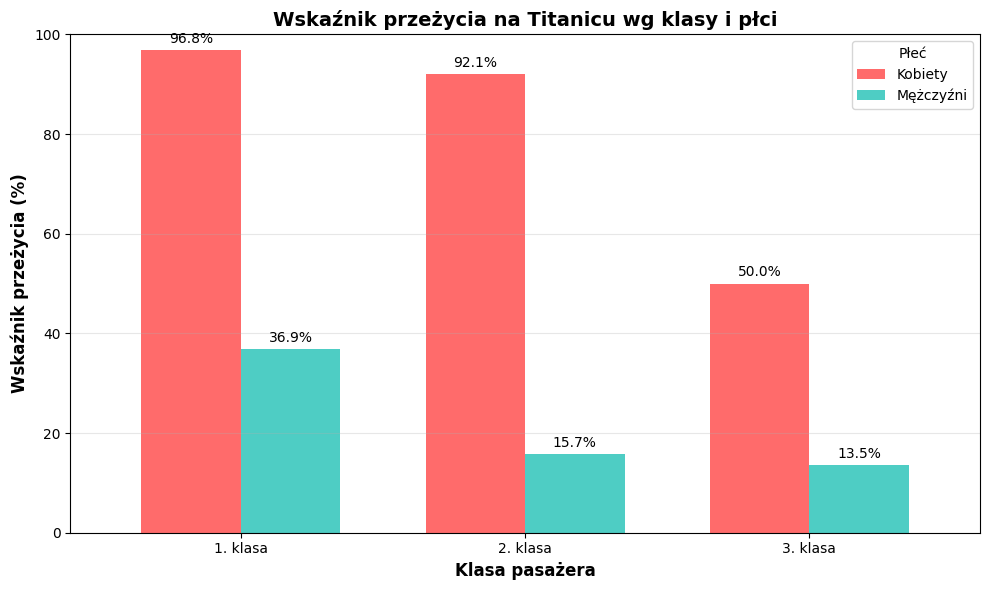

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
url ='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)
# Analiza przeżycia wg klasy i płci
survival_data = titanic.groupby(['Pclass', 'Sex'])['Survived'].agg(['sum',
'count'])
survival_data['survival_rate'] = (survival_data['sum'] /
survival_data['count']) * 100
print("Wskaźniki przeżycia:")
print(survival_data)
# Przygotowanie danych do wykresu
survival_pivot = titanic.pivot_table(
values='Survived',
index='Pclass',
columns='Sex',
aggfunc='mean'
) * 100
# Wykres słupkowy
fig, ax = plt.subplots(figsize=(10, 6))
survival_pivot.plot(kind='bar', ax=ax, color=['#ff6b6b', '#4ecdc4'],
width=0.7)
ax.set_xlabel('Klasa pasażera', fontsize=12, fontweight='bold')
ax.set_ylabel('Wskaźnik przeżycia (%)', fontsize=12, fontweight='bold')
ax.set_title('Wskaźnik przeżycia na Titanicu wg klasy i płci', fontsize=14,
fontweight='bold')
ax.set_xticklabels(['1. klasa', '2. klasa', '3. klasa'], rotation=0)
ax.legend(title='Płeć', labels=['Kobiety', 'Mężczyźni'])
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
# Dodanie wartości na słupkach
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.savefig('titanic_survival_rate.png', dpi=100, bbox_inches='tight')
print("\nWykres zapisany jako: titanic_survival_rate.png")

Liczba NaN w każdej kolumnie:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Procent brakujących wartości:
Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64

Wiersze z co najmniej 1 NaN: 708(79.5%)

Mapa zapisana jako: missing_data_heatmap.png


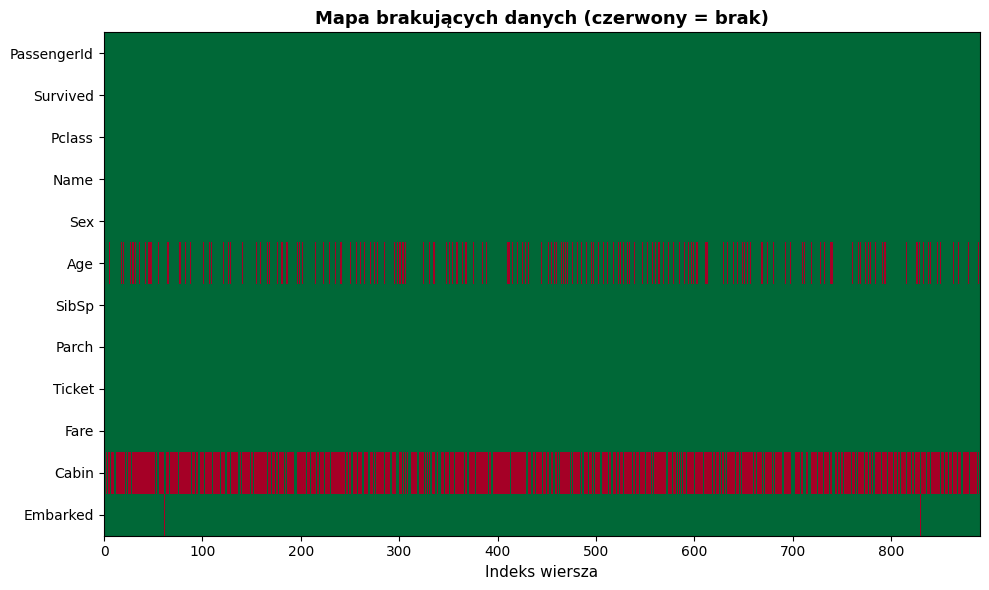

In [28]:
import pandas as pd
import numpy as np
url ='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)
# Sprawdzenie brakujących wartości
print("Liczba NaN w każdej kolumnie:")
print(titanic.isnull().sum()) # lub .isna()
# Procent brakujących wartości
print("\nProcent brakujących wartości:")
missing_percent = (titanic.isnull().sum() / len(titanic)) * 100
print(missing_percent[missing_percent > 0])
# Liczba wierszy z JAKIMIKOLWIEK brakującymi wartościami
rows_with_nan = titanic.isnull().any(axis=1).sum()
print(f"\nWiersze z co najmniej 1 NaN: {rows_with_nan}({rows_with_nan/len(titanic)*100:.1f}%)")
# Wizualizacja brakujących danych - mapa ciepła
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
missing_data = titanic.isnull().astype(int)
ax.imshow(missing_data.T, cmap='RdYlGn_r', aspect='auto',
interpolation='none')
ax.set_yticks(range(len(titanic.columns)))
ax.set_yticklabels(titanic.columns)
ax.set_xlabel('Indeks wiersza', fontsize=11)
ax.set_title('Mapa brakujących danych (czerwony = brak)', fontsize=13,
fontweight='bold')
plt.tight_layout()
plt.savefig('missing_data_heatmap.png', dpi=100, bbox_inches='tight')
print("\nMapa zapisana jako: missing_data_heatmap.png")

In [29]:
import pandas as pd
import numpy as np
url ='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)
# Kopia do testów
titanic_filled = titanic.copy()
# Strategia 1: Wypełnienie konkretną wartością
titanic_filled['Age'].fillna(0, inplace=True)
print("Age po wypełnieniu zerami (pierwsze 10 oryginalnych NaN):")
print(titanic_filled.loc[titanic['Age'].isnull(), 'Age'].head(10))
# Strategia 2: Wypełnienie średnią (dla danych numerycznych)
titanic_filled = titanic.copy()
age_mean = titanic['Age'].mean()
titanic_filled['Age'].fillna(age_mean, inplace=True)
print(f"\nAge po wypełnieniu średnią ({age_mean:.2f}):")
print(titanic_filled['Age'].describe())
# Strategia 3: Wypełnienie medianą (bardziej odporne na outliers)
titanic_filled = titanic.copy()
age_median = titanic['Age'].median()
titanic_filled['Age'].fillna(age_median, inplace=True)
print(f"\nAge po wypełnieniu medianą ({age_median:.2f}):")
print(titanic_filled['Age'].describe())
# Strategia 4: Wypełnienie dominantą (dla kategorii)
titanic_filled = titanic.copy()
embarked_mode = titanic['Embarked'].mode()[0] # Najczęstsza wartość
titanic_filled['Embarked'].fillna(embarked_mode, inplace=True)
print(f"\nEmbarked po wypełnieniu dominantą ('{embarked_mode}'):")
print(titanic_filled['Embarked'].value_counts())
# Strategia 5: Forward fill (propagacja wartości)
titanic_filled = titanic.copy()
titanic_filled['Age'].fillna(method='ffill', inplace=True) # Poprzednia

print("\nAge po forward fill (pierwsze 20):")
print(titanic_filled['Age'].head(20))
# Strategia 6: Backward fill
titanic_filled = titanic.copy()
titanic_filled['Age'].fillna(method='bfill', inplace=True) # Następna

print("\nAge po backward fill (pierwsze 20):")
print(titanic_filled['Age'].head(20))
# Porównanie strategii
print("\n--- Porównanie średniej Age ---")
print(f"Oryginał (bez NaN): {titanic['Age'].mean():.2f}")
print(f"Wypełnienie 0: różnica dużo!")
print(f"Wypełnienie średnią: {age_mean:.2f} (zachowana średnia)")
print(f"Wypełnienie medianą: {age_median:.2f}")

Age po wypełnieniu zerami (pierwsze 10 oryginalnych NaN):
5    NaN
17   NaN
19   NaN
26   NaN
28   NaN
29   NaN
31   NaN
32   NaN
36   NaN
42   NaN
Name: Age, dtype: float64

Age po wypełnieniu średnią (29.70):
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

Age po wypełnieniu medianą (28.00):
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

Embarked po wypełnieniu dominantą ('S'):
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


/var/folders/yj/jl4l61bx379272hbr8ldy_bc0000gn/T/ipykernel_3208/3761554690.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_filled['Age'].fillna(0, inplace=True)
/var/folders/yj/jl4l61bx379272hbr8ldy_bc0000gn/T/ipykernel_3208/3761554690.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series 

TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'

KROK 1: PIERWSZE SPOJRZENIE NA DANE
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0           

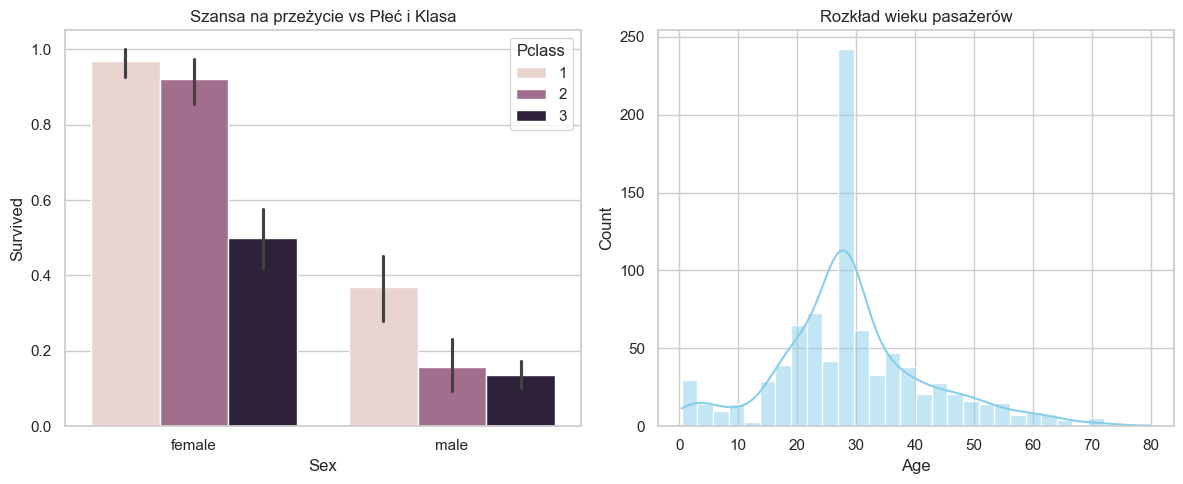


Gotowe! Wykresy powinny pojawić się w nowym oknie.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- KONFIGURACJA WYKRESÓW ---
sns.set_theme(style="whitegrid")

# --- KROK 1: WCZYTANIE DANYCH ---
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

print("=" * 50)
print("KROK 1: PIERWSZE SPOJRZENIE NA DANE")
print("=" * 50)
print(titanic.head())
print(f"\nKształt: {titanic.shape}")

# --- KROK 2: ANALIZA BRAKUJĄCYCH DANYCH ---
print("\n" + "=" * 50)
print("KROK 2: ANALIZA BRAKUJĄCYCH DANYCH")
print("=" * 50)
missing = titanic.isnull().sum()
print(missing[missing > 0])

# --- KROK 3: CZYSZCZENIE DANYCH (Poprawione) ---
print("\n" + "=" * 50)
print("KROK 3: CZYSZCZENIE DANYCH")
print("=" * 50)

# Kopia do czyszczenia
titanic_clean = titanic.copy()

# 1. Usunięcie kolumny 'Cabin'
titanic_clean.drop('Cabin', axis=1, inplace=True)
print("✓ Usunięto kolumnę 'Cabin'")

# 2. Wypełnienie 'Age' medianą - BEZ inplace=True (nowy standard)
age_median = titanic_clean['Age'].median()
titanic_clean['Age'] = titanic_clean['Age'].fillna(age_median)
print(f"✓ Wypełniono 'Age' medianą: {age_median}")

# 3. Wypełnienie 'Embarked' dominantą - BEZ inplace=True
embarked_mode = titanic_clean['Embarked'].mode()[0]
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(embarked_mode)
print(f"✓ Wypełniono 'Embarked' dominantą: '{embarked_mode}'")

# 4. Optymalizacja typów
titanic_clean['Pclass'] = titanic_clean['Pclass'].astype('int8')
titanic_clean['Survived'] = titanic_clean['Survived'].astype('int8')
titanic_clean['Sex'] = titanic_clean['Sex'].astype('category')
titanic_clean['Embarked'] = titanic_clean['Embarked'].astype('category')
print("✓ Zoptymalizowano typy danych")

# --- KROK 4: STATYSTYKI ---
print("\n" + "=" * 50)
print("KROK 4: PODSTAWOWE STATYSTYKI")
print("=" * 50)
print(titanic_clean[['Age', 'Fare']].describe())

# --- KROK 5: WIZUALIZACJA (Seaborn) ---
print("\n" + "=" * 50)
print("KROK 5: GENEROWANIE WYKRESÓW...")
print("=" * 50)

# Tworzymy figurę z dwoma wykresami obok siebie
plt.figure(figsize=(12, 5))

# Wykres 1: Przeżywalność w zależności od płci i klasy
plt.subplot(1, 2, 1)
sns.barplot(data=titanic_clean, x="Sex", y="Survived", hue="Pclass")
plt.title("Szansa na przeżycie vs Płeć i Klasa")

# Wykres 2: Rozkład wieku pasażerów
plt.subplot(1, 2, 2)
sns.histplot(data=titanic_clean, x="Age", kde=True, color="skyblue")
plt.title("Rozkład wieku pasażerów")

plt.tight_layout()
plt.show()

print("\nGotowe! Wykresy powinny pojawić się w nowym oknie.")

Praca domowa 10, 11

10. ✏ Zadanie 10 – Kompleksowe czyszczenie danych
Wyczyść dataset Titanic stosując pełny pipeline:
Usuń kolumny z >60% NaN
Wypełnij Age medianą
Wypełnij Embarked dominantą
Usuń wiersze z pozostałymi NaN
Wymagania:
Przed i po: wypisz kształt DataFrame
Sprawdź czy nie ma NaN
Porównaj rozkład Age przed i po

Baza: 
      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ..

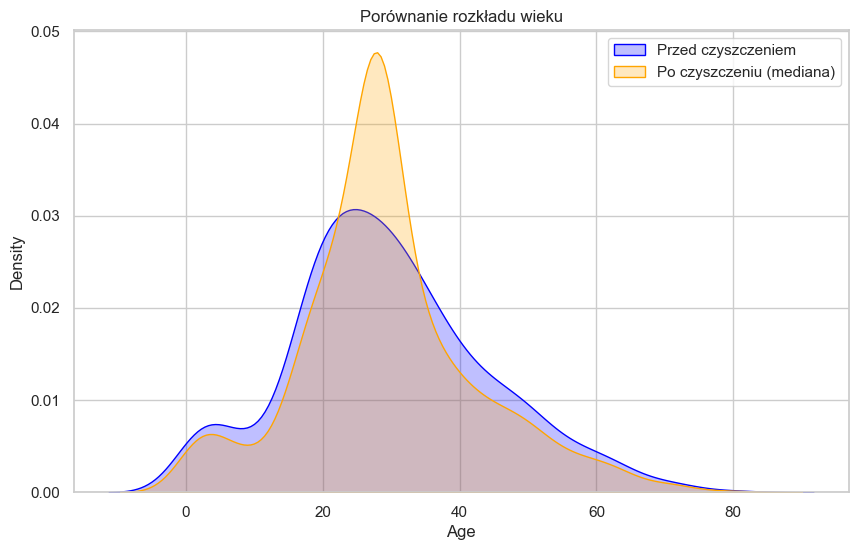

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Baza: \n {df}")

print(f"Wartosci null: {df.isnull().sum()}")

wiek = df["Age"].copy()

threshold = len(df) *0.4
df = df.dropna(thresh=threshold, axis = 1)

print(f"Usunięte kolumny: {set(df.columns)}")

mediana = df["Age"].median()
df["Age"] = df["Age"].fillna(mediana)

dominanta = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(dominanta)

df = df.dropna(axis=0, how="any")

print(f"Jakies braki jeszcze: {df.isnull().sum()}")



plt.figure(figsize=(10,6))
sns.kdeplot(wiek, label="Przed czyszczeniem", fill=True, color="blue")
sns.kdeplot(df["Age"], label="Po czyszczeniu (mediana)", fill=True, color="orange")
plt.title("Porównanie rozkładu wieku")
plt.legend()
plt.show()


In [51]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)


df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

bins = [0, 12, 18, 35, 60, 100]
labels = ['Dziecko', 'Nastolatek', 'Dorosły', 'Starszy', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(df['FamilySize'].value_counts())
print(df['IsAlone'].value_counts())
print(df['AgeGroup'].value_counts())

survival_rate = df.groupby('IsAlone')['Survived'].mean()
print(f"Przezycie: {survival_rate}")

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64
IsAlone
1    537
0    354
Name: count, dtype: int64
AgeGroup
Dorosły       535
Starszy       195
Nastolatek     70
Dziecko        69
Senior         22
Name: count, dtype: int64
Przezycie: IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64
